# Day 2

## Data exploration, cleaning, and feature engineering

Notebook prepared by Nuno R. C. Gomes, IEEC/ICE-CSIC | v20260504

###### Cerdanyola del Vallès, Barcelona, 18-22 May 2026

----

### 📦 Packages

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy import stats

### ⚙️ Configuration

In [8]:
# set visualisation style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Confusion matrix

Let us consider the confusion matrix for **dog** image recognition.

Index | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12
--- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---
Actual/True | dog | cat | cat | cat | dog | cat | dog | dog | dog | dog | dog | cat
Predicted   | dog | cat | dog | dog | dog | cat | dog | cat | dog | dog | dog | cat
Result      | TP  | TN  | FP  | FP  | TP  | TN  | TP  | FN  | TP  | TP  | TP  | TN

- Actual dogs: 7
- Actual not dogs: 5
- True positives (TP): 6
- False positive (FP): 2
- True negatives (TN): 3
- False negatives (FN): 1

|      |          | Predicted | Predicted |
| ---  | ---      | ---       | ---       |
|      |          | Positive  | Negative  |
| True | Positive |    6      |    1      |
| True | Negative |    2      |    3      |

- Accuracy = 0.75
- Precision = 0.75
- Recall = 0.86
- F1-score = 0.80

##### Create the confusion matrix for this case and plot it using `sns.heatmap()`.

##### Print the classifications report based on confusion metrics.
> Hint: use the function `classification_report()`.

In [ ]:
# actual labels
actual = np.array(
  [
    'dog', 'cat', 'cat', 'cat', 'dog', 'cat',
    'dog', 'dog', 'dog', 'dog', 'dog', 'cat'
  ]
)

# predicted labels
predicted = np.array(
  [
    'dog', 'cat', 'dog', 'dog', 'dog', 'cat',
    'dog', 'cat', 'dog', 'dog', 'dog', 'cat'
  ]
)

# confucion matrix
cm = confusion_matrix(actual, predicted)
print(cm)

[[3 2]
 [1 6]]


In [ ]:
# great suggestion by Alejandro 🙏
pd.crosstab(actual, predicted, margins=True)

col_0,cat,dog,All
row_0,,,
cat,3,2,5
dog,1,6,7
All,4,8,12


In [ ]:
tn, fp, fn, tp = cm.ravel().tolist()
print(f"{tn = }")
print(f"{fp = }")
print(f"{fn = }")
print(f"{tp = }")

tn = 3
fp = 2
fn = 1
tp = 6


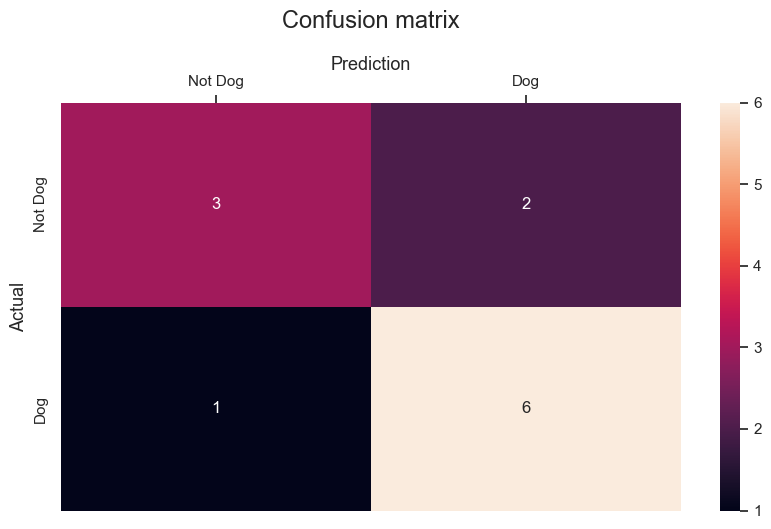

In [ ]:
sns.heatmap(
  cm,
  annot=True, fmt='g',
  xticklabels=["Not Dog", "Dog"], yticklabels=["Not Dog", "Dog"]
)
plt.ylabel("Actual", fontsize=13)
plt.title('Confusion matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel("Prediction", fontsize=13)
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)

In [ ]:
print(classification_report(actual, predicted))

              precision    recall  f1-score   support

         cat       0.75      0.60      0.67         5
         dog       0.75      0.86      0.80         7

    accuracy                           0.75        12
   macro avg       0.75      0.73      0.73        12
weighted avg       0.75      0.75      0.74        12



### 🧹 Data cleaning

We are going to use the Titanic data set to understand and practice some standard data cleaning steps.

In [11]:
# read titanic data
df = pd.read_csv("data/titanic.csv")

# get info of data
df.info()

# get overall view of data frame
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
# find duplicated cases
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [14]:
# exercise: how can you get the total number of duplicate cases?
# add code inside the curly braces, {}, to accomplish the task
print(f"{df.duplicated().sum() = }")

df.duplicated().sum() = np.int64(0)


In [15]:
# find columns with categorical data types
cat_col = [col for col in df.columns if df[col].dtype == 'str']
num_col = [col for col in df.columns if df[col].dtype != 'str']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)
print(f"{cat_col = }")
print(f"{num_col = }")

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_col = ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
num_col = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [16]:
# find how many unique values in the categorical variables
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [17]:
# calculate percentage of missing values
round((df.isnull().sum() / df.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [19]:
# drop irrelevant columns or those with lots of missing values
df1 = df.drop(columns=['Name', 'Ticket', 'Cabin']).copy()
df1 = df1.dropna(subset=['Embarked'])
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())
df1.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


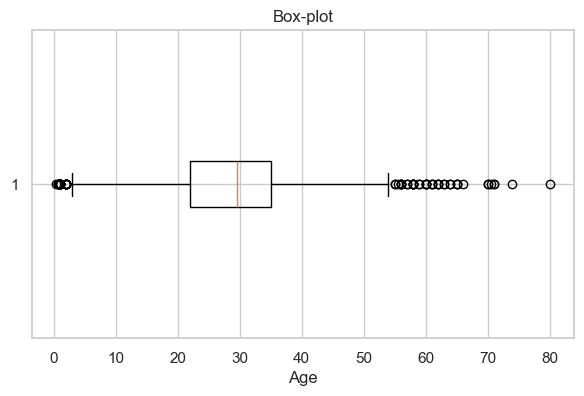

In [20]:
# detect outliers for age with a box-plot
plt.figure(figsize=(7, 4))
plt.boxplot(df1['Age'], vert=False)
plt.xlabel("Age")
plt.title("Box-plot");

The following code attempts to remove outliers and impute missing values.
It contains several bad practices and some inconsistencies.
Can you find them?

In [21]:
# calculate outlier boundaries and remove them
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2*std
upper_bound = mean + 2*std

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

In [23]:
# impute missing data
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

Lower Bound : 8.978989004171453
Upper Bound : 49.30395961288914


In [26]:
# define X as the set of predictors
X = df4[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
# define y as the target variable
y = df4[['Survived']]
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.000000,1,0,7.2500,S
1,1,female,38.000000,1,0,71.2833,C
2,3,female,26.000000,0,0,7.9250,S
3,1,female,35.000000,1,0,53.1000,S
4,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.000000,0,0,13.0000,S
887,1,female,19.000000,0,0,30.0000,S
888,3,female,29.642093,1,2,23.4500,S
889,1,male,26.000000,0,0,30.0000,C


Here's a different strategy:

Lower bound for outliers: 2.5
Upper bound for outliers: 54.5


Text(0.5, 1.0, 'Cleaned box-plot (outliers removed)')

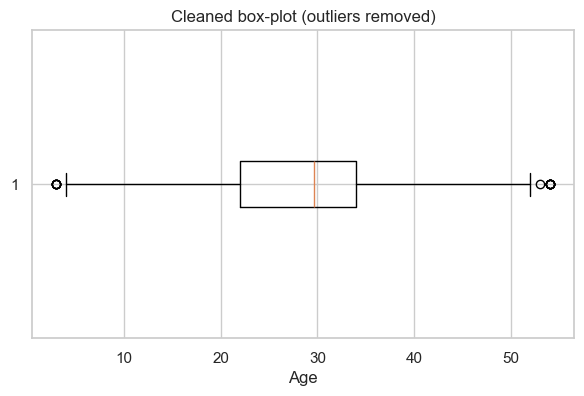

In [24]:
df_clean = df1.copy()

# 1. impute missing values FIRST (targeting ONLY the 'Age' column)
# using median because it is robust against any extreme outliers currently in the data
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)

# 2. define outlier boundaries using the IQR method (matching the boxplot logic)
Q1 = df_clean['Age'].quantile(0.25)
Q3 = df_clean['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

# 3. filter out the outliers ONCE
df_final = df_clean[
  (df_clean['Age'] >= lower_bound) & (df_clean['Age'] <= upper_bound)
].copy()

# 4. visualise the final, cleaned distribution
plt.figure(figsize=(7, 4))
plt.boxplot(df_final['Age'], vert=False)
plt.xlabel("Age")
plt.title("Cleaned box-plot (outliers removed)")

In [ ]:
# display the first ten rows of the final data frame


In [ ]:
# improvement (possibly):
# impute Age based on the median of the passenger's specific Class and Sex group
df_clean['Age'] = df_clean['Age'].fillna(
  df_clean.groupby(['Pclass', 'Sex'])['Age'].transform('median')
)
# repeat the code above with this change in the imputation step and check if the
# results improved


### 🗂️ 🐧 Penguins data set

We will use the "Palmer Penguins" data set (a modern alternative to Iris).
It contains morphological measurements for three penguin species.

In [29]:
# path to save CSV
file_path = Path("data/penguins.csv")

# check if file exists
if file_path.exists():
  # load from local CSV
  df = pd.read_csv(file_path)
  print(f"Loaded data set from {file_path}")
else:
  # ensure data/ directory exists (create it otherwise)
  file_path.parent.mkdir(parents=True, exist_ok=True)
  # url of data set
  url = (
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/"
    "inst/extdata/penguins.csv"
  )
  # read CSV from web
  df = pd.read_csv(url)
  # save CSV to data/
  df.to_csv(file_path, index=False)
  print(f"Saved data set to {file_path}")

Loaded data set from data/penguins.csv


### 🔍 Exploratory data analysis (EDA)

In this section, we explore the data set to understand its structure, distributions, and relationships between variables.
Through visualisations and summary statistics, we aim to uncover patterns, spot anomalies, and generate insights that will guide subsequent analysis and modelling.

In [30]:
print("--- Data set info ---")
df.info()

--- Data set info ---
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [31]:
print("\n--- Summary statistics ---")
df.describe()


--- Summary statistics ---


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


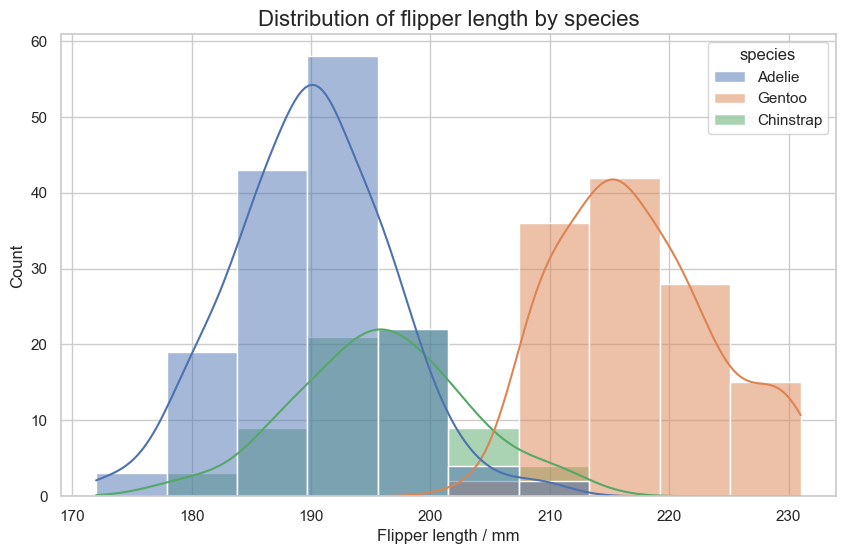

In [32]:
# visualise distributions
sns.histplot(data=df, x="flipper_length_mm", hue="species", kde=True)
plt.title("Distribution of flipper length by species", fontsize=16)
plt.xlabel("Flipper length / mm");

### 🔧 Data Wrangling
In this section, we clean and prepare the data set by handling missing values, treating outliers, creating new features, and applying PCA for dimensionality reduction.
These steps ensure our data are reliable, meaningful, and ready for analysis or modelling.

#### Missing values

In [33]:
print("\n--- Missing values count ---")
df.isnull().sum()


--- Missing values count ---


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

#### Data imputation

In [34]:
# simple imputation for numerical columns
# use median to avoid outlier influence
df['bill_length_mm'] = df['bill_length_mm'].fillna(
  df['bill_length_mm'].median()
)

df['bill_depth_mm'] = df['bill_depth_mm'].fillna(
  df['bill_depth_mm'].median()
)

df['flipper_length_mm'] = df['flipper_length_mm'].fillna(
  df['flipper_length_mm'].median()
)

df['body_mass_g'] = df['body_mass_g'].fillna(
  df['body_mass_g'].median()
)

df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,NaN,2007
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.80,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.50,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.60,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.80,19.0,210.0,4100.0,male,2009


In [35]:
df.isnull().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
body_mass_g           0
sex                  11
year                  0
dtype: int64

In [36]:
# drop rows with missing categorical labels (sex)
df = df.dropna(subset=['sex'])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


#### Handling outliers

In [37]:
# calculate Z-scores for bill depth
z_scores = np.abs(stats.zscore(df['bill_depth_mm'].dropna()))
# filter out rows where z-score > 3 (anomalies)
df_clean = df[
  (np.abs(stats.zscore(df.select_dtypes(include=[np.number]))) < 3).all(axis=1)
]
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


#### Feature engineering and scaling

In [38]:
# make copy of data frame
df0 = df.copy()

# create new feature: body mass [kg]
df['body_mass_kg'] = df['body_mass_g'] / 1000

# one-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=['island', 'sex'])

# scaling numerical features
scaler = StandardScaler()
num_cols = [
  'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_kg'
]
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# first five rows after preprocessing
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,3.65


#### Dimensionality reduction (PCA)


Explained variance ratio by component:
[0.68633893 0.19452929]


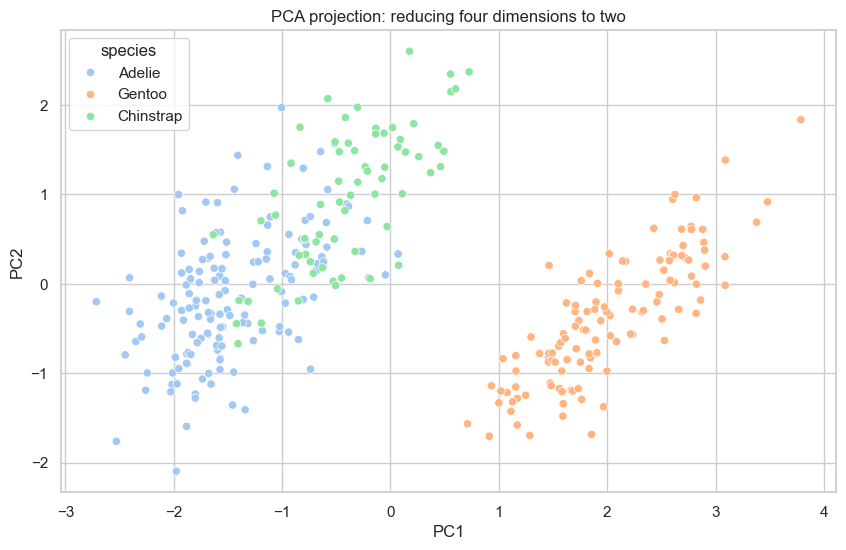

In [39]:
# prepare data for PCA (drop non-numeric and target)
features = df_encoded[num_cols]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features)

# create data frame for visualisation
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['species'] = df['species'].values

# visualise PCA projection
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species', palette='pastel')
plt.title("PCA projection: reducing four dimensions to two");

print("\nExplained variance ratio by component:")
print(pca.explained_variance_ratio_)

Can you find which of the raw features make up, for instance, PC1?

In [40]:
# extract the components (loadings) matrix
loadings = pca.components_

# create DataFrame where columns are original raw features
df_loadings = pd.DataFrame(
  data=loadings, 
  columns=features.columns, 
  index=['PC1', 'PC2']
)

# display matrix transposed so it is easier to read vertically
print("PCA loadings matrix (feature contributions):")
print(df_loadings.T)

PCA loadings matrix (feature contributions):
                        PC1       PC2
bill_length_mm     0.453753  0.600195
bill_depth_mm     -0.399047  0.796170
flipper_length_mm  0.576825  0.005788
body_mass_kg       0.549675  0.076464


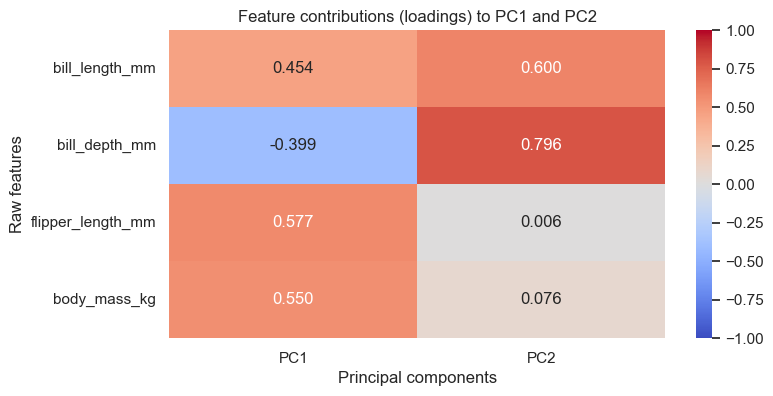

In [41]:
plt.figure(figsize=(8, 4))
# plot transposed loadings matrix
sns.heatmap(
  df_loadings.T, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f"
)
plt.title("Feature contributions (loadings) to PC1 and PC2")
plt.ylabel("Raw features")
plt.xlabel("Principal components");

In [42]:
# for PC1 (index 0)
pc1_importance = pd.DataFrame({
  'Feature': features.columns,
  'Loading': pca.components_[0]
}).sort_values(by='Loading', key=abs, ascending=False)

print("--- Top features driving PC1 ---")
print(pc1_importance)

# for PC2 (index 1)
pc2_importance = pd.DataFrame({
  'Feature': features.columns,
  'Loading': pca.components_[1]
}).sort_values(by='Loading', key=abs, ascending=False)

print("\n--- Top features driving PC2 ---")
print(pc2_importance)

--- Top features driving PC1 ---
             Feature   Loading
2  flipper_length_mm  0.576825
3       body_mass_kg  0.549675
0     bill_length_mm  0.453753
1      bill_depth_mm -0.399047

--- Top features driving PC2 ---
             Feature   Loading
1      bill_depth_mm  0.796170
0     bill_length_mm  0.600195
3       body_mass_kg  0.076464
2  flipper_length_mm  0.005788
